In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('../data/tanzania.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [3]:

print(df.shape)
print(df.shape[0],df.shape[1])
print(df.columns.tolist()) 
df.info()

(4108, 12)
4108 12
['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
<class 'pandas.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64
 4   T2M_MIN      4108 non-null   float64
 5   T2M_RANGE    4108 non-null   float64
 6   PRECTOTCORR  4108 non-null   float64
 7   RH2M         4108 non-null   float64
 8   WS2M         4108 non-null   float64
 9   WS2M_MAX     4108 non-null   float64
 10  PS           4108 non-null   float64
 11  QV2M         4108 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 385.3 KB


In [4]:
df['Country'] = 'Tanzania'
df['Date'] = pd.to_datetime(df['YEAR']*1000 + df['DOY'],format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [5]:
print(df.duplicated().sum())

0


In [6]:
print(f"Number of -999 values before replacement: {(df == -999).sum().sum()}")

Number of -999 values before replacement: 0


In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046,3.248907


In [8]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
df_outliers = df[weather_cols].copy()
z_scores = np.abs(stats.zscore(df_outliers))
outliers = (z_scores > 3)

# This gives you counts PER COLUMN
outlier_counts = outliers.sum()
print("Outlier counts per column:")
print(outlier_counts)

# This gives you total rows with at least one outlier
outlier_rows = outliers.any(axis=1).sum()
print(f"\nTotal rows with at least one outlier: {outlier_rows}")

Outlier counts per column:
102

Total rows with at least one outlier: 97


In [9]:
import os
makedir = os.makedirs('data',exist_ok=True)
df.to_csv('../data/tanzania_clean.csv')

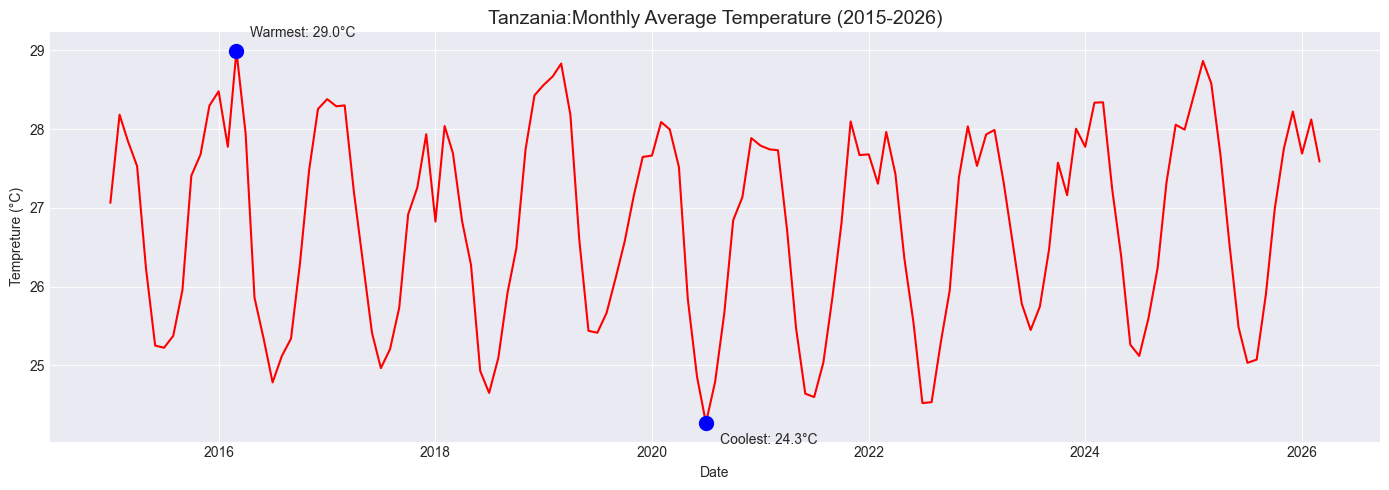

In [10]:
#plot for monthly tanzania temprature data
monthly_temp = df.groupby(['Year','Month'])['T2M'].mean().reset_index()  #this creates a table called monthly_temp that holds average of each month of each year
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str)+'-'+monthly_temp['Month'].astype(str))

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(monthly_temp['Date'],monthly_temp['T2M'],color='red',linewidth=1.5)

warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

ax.scatter(warmest['Date'],warmest['T2M'],color='blue',s=100,zorder=5)
ax.scatter(coolest['Date'],coolest['T2M'],color='blue',s=100,zorder=5)

ax.set_title('Tanzania:Monthly Average Temperature (2015-2026)',fontsize=14)
ax.annotate(f'Warmest: {warmest["T2M"]:.1f}°C', 
            xy=(warmest['Date'], warmest['T2M']),
            xytext=(10, 10), textcoords='offset points', fontsize=10)

ax.annotate(f'Coolest: {coolest["T2M"]:.1f}°C',
            xy=(coolest['Date'], coolest['T2M']), #xy cordiante where the point will be
            xytext=(10, -15), textcoords='offset points', fontsize=10)

ax.set_xlabel('Date')
ax.set_ylabel('Tempreture (°C)')
ax.grid(True,alpha =0.9)

plt.tight_layout()
plt.show() 

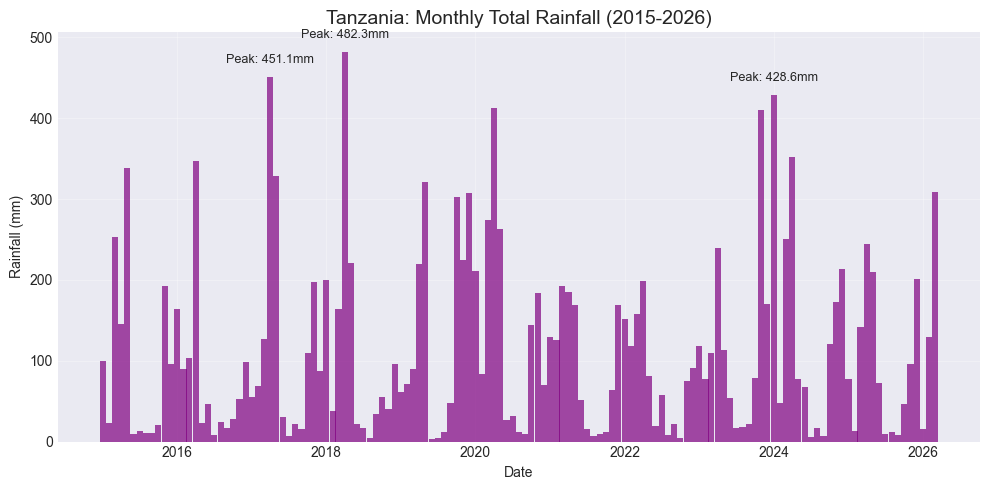

In [11]:
#plot for monthly tanzania rain graph
monthly_rain = df.groupby(['Year','Month'])['PRECTOTCORR'].sum().reset_index()
monthly_rain['Date'] = pd.to_datetime(monthly_rain['Year'].astype(str)+'-'+monthly_rain['Month'].astype(str))

#let us plot the graph
fig, ax = plt.subplots(figsize=(10,5))

bars = ax.bar(monthly_rain['Date'], monthly_rain['PRECTOTCORR'], width=30,color='purple',alpha=0.7)

peak_months = monthly_rain.nlargest(3, 'PRECTOTCORR')

for _, row in peak_months.iterrows():
    ax.annotate(f'Peak: {row["PRECTOTCORR"]:.1f}mm',
                xy=(row['Date'], row['PRECTOTCORR']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)

ax.set_title('Tanzania: Monthly Total Rainfall (2015-2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Rainfall (mm)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

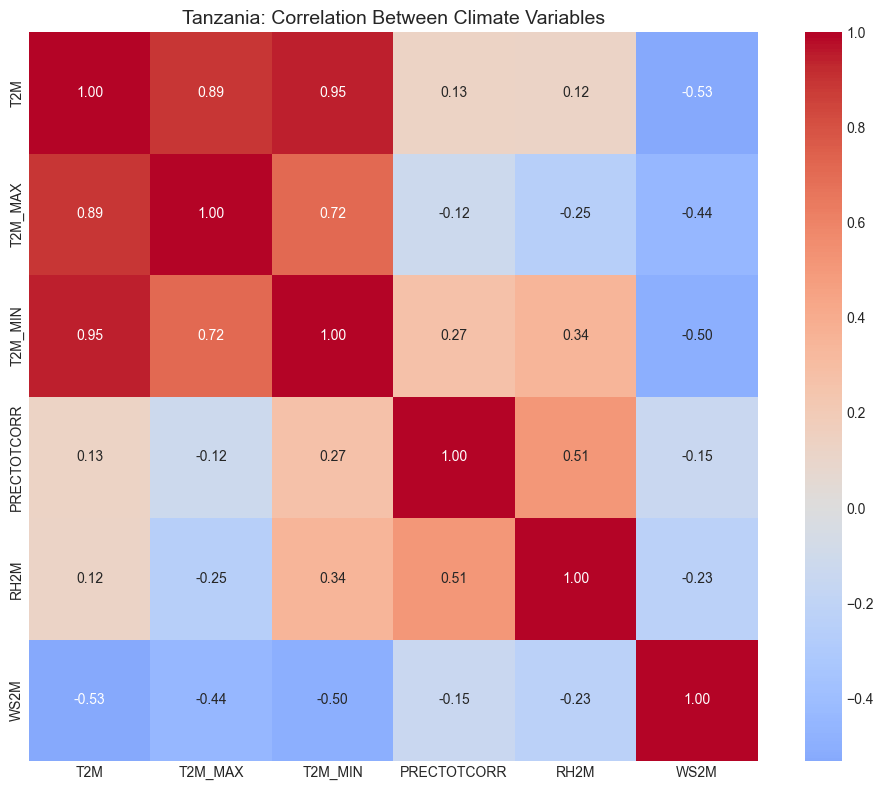

In [12]:

corr_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
corr_matrix = df[corr_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True,
             cmap='coolwarm',
             center=0, 
            fmt='.2f', square=True, ax=ax)

ax.set_title('Tanzania: Correlation Between Climate Variables', fontsize=14)

plt.tight_layout()
plt.show()

# Find strongest correlations
# Get upper triangle of correlation matrix (excluding diagonal)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong_corrs = upper_tri.unstack().dropna().abs().sort_values(ascending=False)

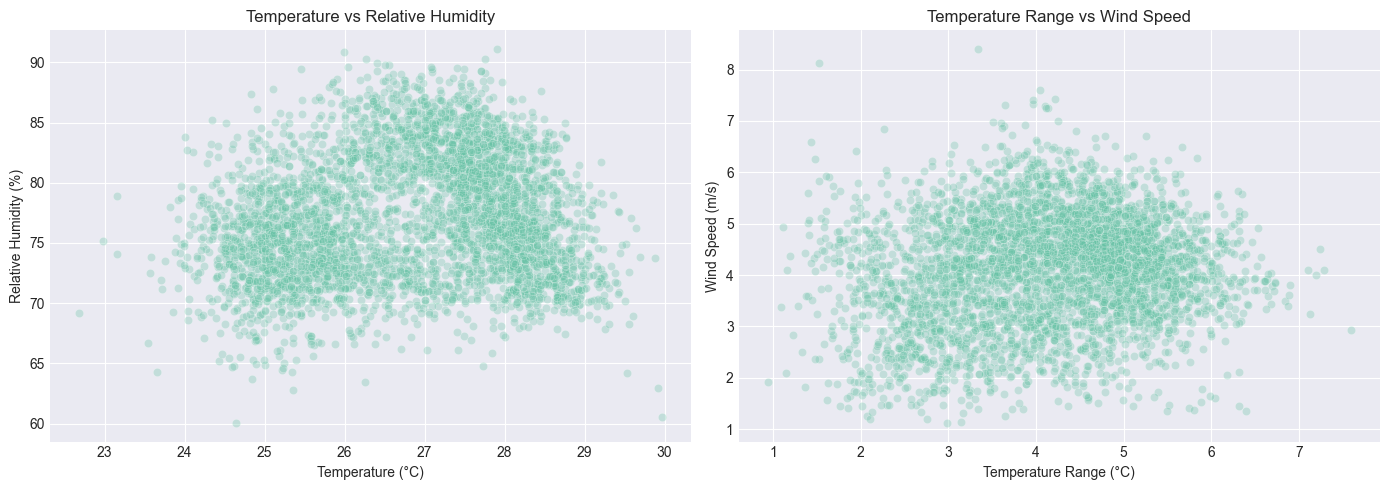

In [13]:
# Create scatter plots
fig, axes = plt.subplots(1, 2
                         ,figsize=(14, 5))

# Scatter 1: Temperature vs Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')

# Scatter 2: Temperature Range vs Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=axes[1])
axes[1].set_title('Temperature Range vs Wind Speed')
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

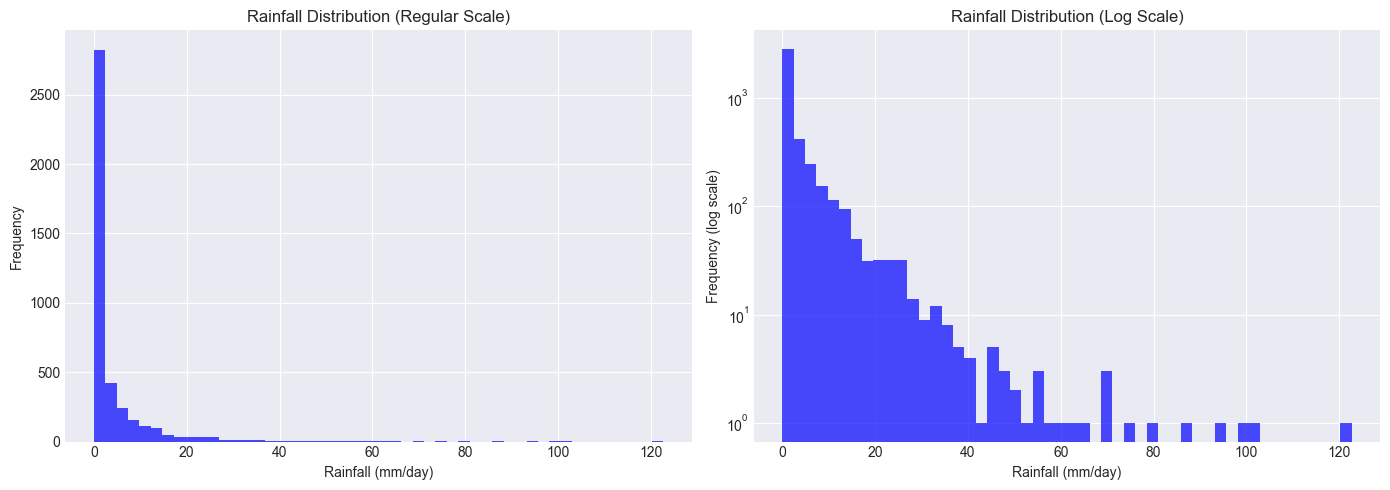

In [15]:
# Rainfall histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regular scale
axes[0].hist(df['PRECTOTCORR'].dropna(), bins=50
             , color='blue', alpha=0.7)
axes[0].set_title('Rainfall Distribution (Regular Scale)')
axes[0].set_xlabel('Rainfall (mm/day)')
axes[0].set_ylabel('Frequency')

# Log scale (to see pattern better)
axes[1].hist(df['PRECTOTCORR'].dropna(), bins=50, color='blue', alpha=0.7, log=True)
axes[1].set_title('Rainfall Distribution (Log Scale)')
axes[1].set_xlabel('Rainfall (mm/day)')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

In [ ]:
# Bubble chart: Temperature vs Humidity, size = Rainfall
sample = df.dropna(subset=['T2M', 'RH2M', 'PRECTOTCORR'])

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(sample['T2M'], sample['RH2M'], 
                     s=sample['PRECTOTCORR'] * 5,  # Size proportional to rainfall
                     alpha=0.6, c=sample['PRECTOTCORR'], cmap='coolwarm'
                     )

ax.set_title('Tanzania: Temperature vs Humidity (Bubble size = Rainfall)', fontsize=14)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Relative Humidity (%)')

plt.colorbar(scatter, label='Rainfall (mm/day)')
plt.tight_layout()
plt.show()